</table><table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 17 - Ejemplo 2 - Árboles de decisión
        </td>
    </tr>
    <tr>
 

</table>

In [2]:
import numpy as np
import pandas as pd
import array
import matplotlib.pyplot as plt
import seaborn as sns
import math
from plotnine import *
from array import*
import scipy.stats as stats
from sklearn.linear_model import LinearRegression 
from sklearn.datasets import make_classification
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from sklearn.metrics import accuracy_score
import statsmodels.api as sm
import os, sys

from Parcial2.Parcial2_20231085 import random_state

Se dispone de un conjunto de datos con 100 registros relacionados con viviendas. El conjunto contiene información sobre el tamaño de la casa, la distancia hacia la ciudad, la ubicación y el precio de cada vivienda.

El objetivo es construir un modelo de árbol de decisión para regresión que permita predecir el precio de una vivienda a partir de sus características.

La variable dependiente es `Price`, la cual representa el precio de la vivienda.

Las variables predictoras son:

- `HouseSize`: tamaño de la vivienda.
- `DistanceToCity`: distancia de la vivienda hacia la ciudad.
- `Location`: ubicación o zona donde se encuentra la vivienda.

El conjunto de datos presenta valores nulos en las variables `HouseSize` y `DistanceToCity`, por lo que será necesario tratarlos antes de entrenar el modelo. Además, la variable `Location` es categórica, por lo que deberá codificarse numéricamente.


a) Realizar una exploración inicial del conjunto de datos.

b) Tratar los valores nulos de `HouseSize` y `DistanceToCity`.

c) Dividir el conjunto de datos en 75 % entrenamiento y 25 % validación.

d) Crear un árbol de decisión para regresión con parámetros por defecto.

e) Crear un árbol de decisión para regresión con `max_depth=3`.

f) Crear un árbol de decisión usando otro hiperparámetro, como `min_samples_leaf` o `max_leaf_nodes`.

g) Utilizar el mejor modelo para predecir el precio de una vivienda.

In [3]:
datos = pd.read_csv("multiple_linear.csv")
datos

,HouseSize,DistanceToCity,Location,Price
0,NaN,22.92,B,20.74
1,48.6,27.90,B,19.35
2,NaN,28.29,A,23.30
3,65.2,25.99,A,25.37
4,47.7,29.19,A,19.66
...,...,...,...,...
95,115.4,81.93,C,45.12
96,133.0,75.58,C,50.43
97,132.6,80.77,B,50.44
98,130.1,80.29,C,52.66


In [4]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   HouseSize       95 non-null     float64
 1   DistanceToCity  95 non-null     float64
 2   Location        100 non-null    str    
 3   Price           100 non-null    float64
dtypes: float64(3), str(1)
memory usage: 3.4 KB


In [5]:
X_independientes = datos[["HouseSize", "DistanceToCity"]].copy()
y_dependiente = datos["Price"].copy()

<Figure size 640x480 with 0 Axes>

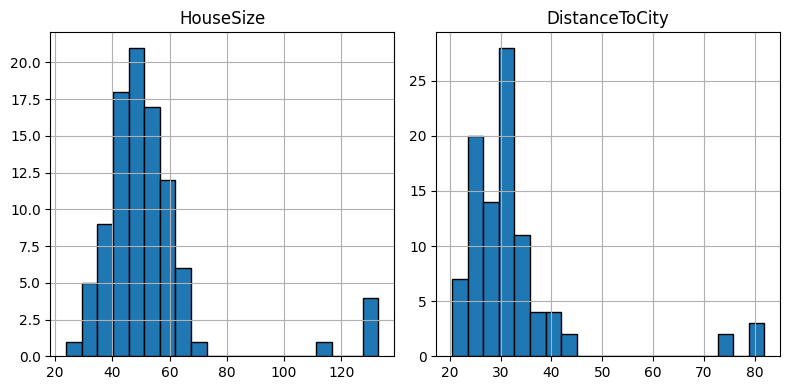

In [6]:
plt.figure()
X_independientes.hist(figsize=(8,4),  bins=20, edgecolor="black")
plt.tight_layout()
plt.show()

In [7]:
from sklearn.impute import SimpleImputer
imputador = SimpleImputer(strategy="median")

#Se calcula la imputacion
imputador.fit(X_independientes)

#Se aplica la imputacion
X_independientes_i = imputador.transform(X_independientes)
X_independientes_i = pd.DataFrame(X_independientes_i, columns = X_independientes.columns)

In [8]:
from sklearn.model_selection import train_test_split

#Obtenemos las muestras de entrenamiento y test por medio de la función train_test_split
X_train, X_test, y_train, y_test= train_test_split(X_independientes_i,y_dependiente, test_size=0.25, random_state=2026)

In [9]:
from sklearn.tree import DecisionTreeRegressor

#Crear el objeto de clase árbol
tree_clf = DecisionTreeRegressor(random_state = 2026)
#Ajustar el arbol
tree_clf.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",2026
,"max

In [10]:
#Obtener el accuracy_score
y_pred_a = tree_clf.predict(X_test)
r2_a = r2_score(y_test, y_pred_a)
mse_a = mean_squared_error(y_test, y_pred_a)
print("El error cuadrático medio que se tiene es %s" %mse_a)
print("El r2 que se tiene es %s" %r2_a)

El error cuadrático medio que se tiene es 3.6985519999999985
El r2 que se tiene es 0.9671851533433606


El árbol de decisión para regresión obtuvo un error cuadrático medio de 6.9493, lo cual indica que, en promedio, los errores al cuadrado entre los precios reales y los precios predichos son bajos. El valor de $R^2$ de 0.9413 indica que el modelo tiene una alta capacidad predictiva, ya que logra explicar aproximadamente el 94.13 % de la variación observada en los precios de las viviendas a partir de las variables

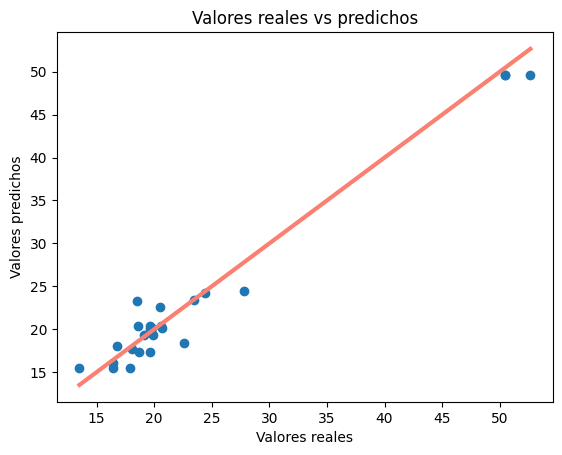

In [11]:
plt.figure()
plt.scatter(y_test,y_pred_a)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Valores reales vs predichos")
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color='salmon',linewidth='3')
plt.show()

[Text(0.5909090909090909, 0.875, 'x[0] <= 91.95\nsquared_error = 26.36\nsamples = 75\nvalue = 21.853'),
 Text(0.36363636363636365, 0.625, 'x[0] <= 55.25\nsquared_error = 8.616\nsamples = 73\nvalue = 21.154'),
 Text(0.4772727272727273, 0.75, 'True  '),
 Text(0.18181818181818182, 0.375, 'x[0] <= 44.2\nsquared_error = 4.726\nsamples = 55\nvalue = 19.945'),
 Text(0.09090909090909091, 0.125, 'squared_error = 1.913\nsamples = 16\nvalue = 17.576'),
 Text(0.2727272727272727, 0.125, 'squared_error = 2.632\nsamples = 39\nvalue = 20.917'),
 Text(0.5454545454545454, 0.375, 'x[0] <= 59.85\nsquared_error = 2.396\nsamples = 18\nvalue = 24.847'),
 Text(0.45454545454545453, 0.125, 'squared_error = 0.896\nsamples = 8\nvalue = 23.569'),
 Text(0.6363636363636364, 0.125, 'squared_error = 1.242\nsamples = 10\nvalue = 25.87'),
 Text(0.8181818181818182, 0.625, 'x[1] <= 78.11\nsquared_error = 5.063\nsamples = 2\nvalue = 47.37'),
 Text(0.7045454545454546, 0.75, '  False'),
 Text(0.7272727272727273, 0.375, 'squa

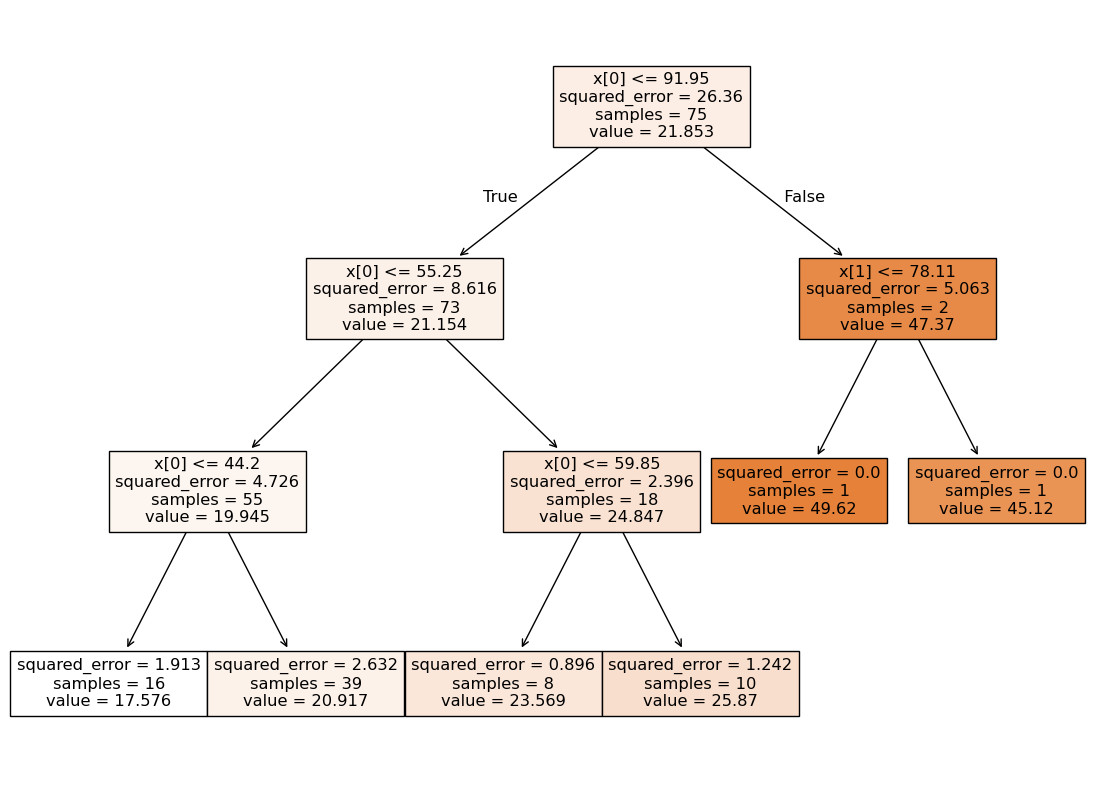

In [18]:
#Crear el objeto de clase árbol profundidad max de 3
tree_clf_b = DecisionTreeRegressor(random_state = 2026, max_depth = 3)
#Ajustar el árbol
tree_clf_b.fit(X_train, y_train)

from sklearn import tree
plt.figure(figsize=(14,10))
tree.plot_tree(tree_clf_b, filled=True)

In [13]:
#Obtener el mse y el r2
y_pred_b = tree_clf_b.predict(X_test)
r2_b = r2_score(y_test, y_pred_b)
mse_b = mean_squared_error(y_test, y_pred_b)
print("El error cuadratico medio que se tiene es %s" %mse_b)
print("El r2 que se tiene es %s" %r2_b)

El error cuadratico medio que se tiene es 6.150027300008214
El r2 que se tiene es 0.9454348072478322


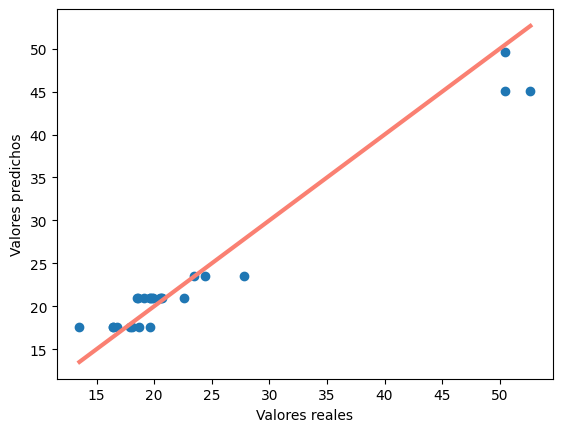

In [16]:
plt.figure()
plt.scatter(y_test,y_pred_b)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.plot([min(y_test), max(y_test)],[min(y_test),max(y_test)],color='salmon',linewidth='3')
plt.show()

El segundo árbol de decisión obtuvo un error cuadrático medio de 8.4475. Este valor indica que, en promedio, los errores al cuadrado entre los precios reales y los precios predichos siguen siendo bajos, aunque son ligeramente mayores que los obtenidos con el primer árbol. El valor de $R^2$ de 0.9286 indica que el segundo árbol tiene una alta capacidad predictiva, ya que logra explicar alrededor del 92.86 % de la variación observada en la variable Price

[Text(0.6, 0.9166666666666666, 'x[0] <= 62.1\nsquared_error = 26.36\nsamples = 75\nvalue = 21.853'),
 Text(0.5, 0.75, 'x[0] <= 48.95\nsquared_error = 6.382\nsamples = 66\nvalue = 20.611'),
 Text(0.55, 0.8333333333333333, 'True  '),
 Text(0.2, 0.5833333333333334, 'x[0] <= 43.75\nsquared_error = 2.828\nsamples = 31\nvalue = 18.745'),
 Text(0.1, 0.4166666666666667, 'squared_error = 1.776\nsamples = 14\nvalue = 17.352'),
 Text(0.3, 0.4166666666666667, 'x[0] <= 46.4\nsquared_error = 0.779\nsamples = 17\nvalue = 19.893'),
 Text(0.2, 0.25, 'squared_error = 0.249\nsamples = 9\nvalue = 19.728'),
 Text(0.4, 0.25, 'squared_error = 1.31\nsamples = 8\nvalue = 20.079'),
 Text(0.8, 0.5833333333333334, 'x[0] <= 55.25\nsquared_error = 3.717\nsamples = 35\nvalue = 22.263'),
 Text(0.7, 0.4166666666666667, 'x[1] <= 25.815\nsquared_error = 2.919\nsamples = 24\nvalue = 21.495'),
 Text(0.6, 0.25, 'squared_error = 2.329\nsamples = 8\nvalue = 20.388'),
 Text(0.8, 0.25, 'x[1] <= 30.585\nsquared_error = 2.294\ns

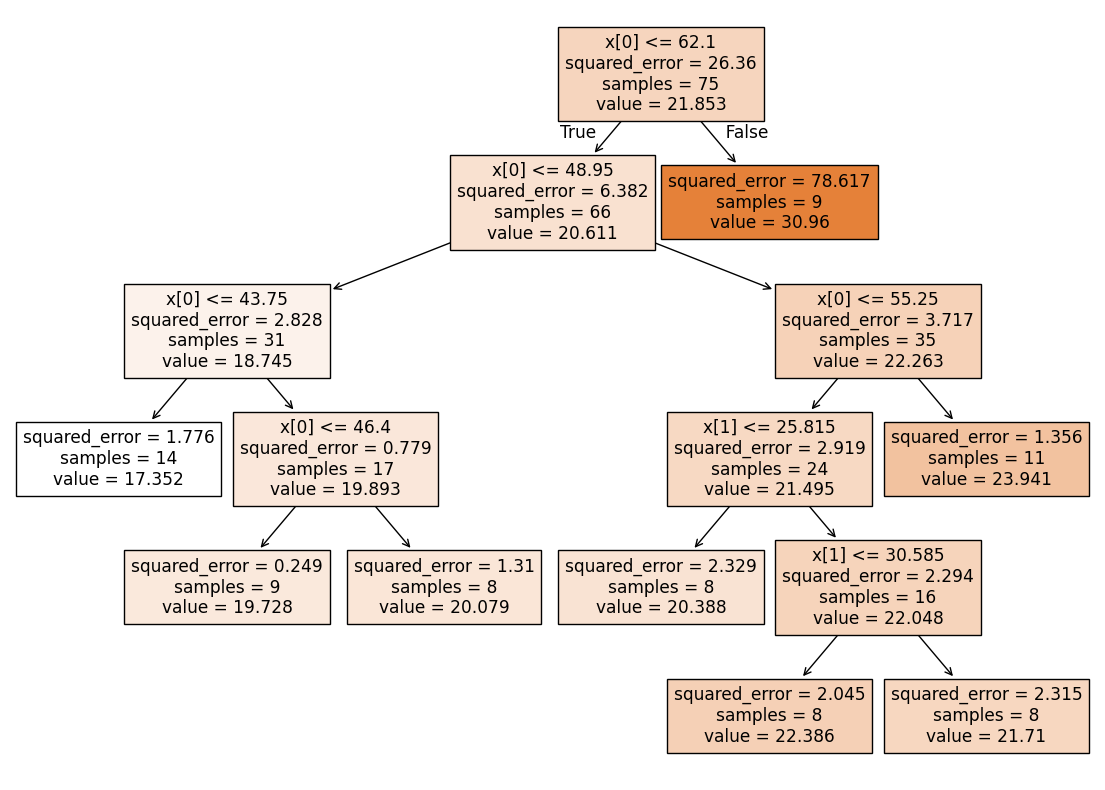

In [17]:
from sklearn.tree import DecisionTreeRegressor

#Crear el objeto de clase árbol num min de muestras 8
tree_clf_c = DecisionTreeRegressor(random_state = 2026, min_samples_leaf = 8)
#Ajustar el árbol
tree_clf_c.fit(X_train, y_train)

from sklearn import tree
plt.figure(figsize=(14,10))
tree.plot_tree(tree_clf_c, filled=True)

In [21]:
#Obtener el mse y el r2
y_pred_c = tree_clf_c.predict(X_test)
r2_c = r2_score(y_test, y_pred_c)
mse_c = mean_squared_error(y_test, y_pred_c)
print("El error cuadratico medio que se tiene es %s" %mse_c)
print("El r2 que se tiene es %s" %r2_c)

El error cuadratico medio que se tiene es 51.5751973429921
El r2 que se tiene es 0.5424068143164669


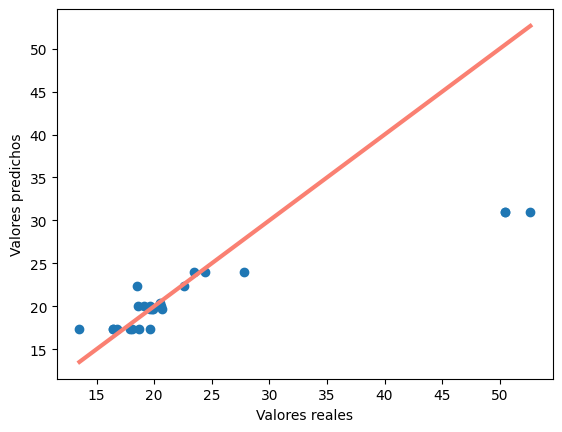

In [22]:
plt.figure()
plt.scatter(y_test,y_pred_c)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.plot([min(y_test), max(y_test)],[min(y_test),max(y_test)],color='salmon',linewidth='3')
plt.show()

El tercer árbol de decisión obtuvo un error cuadrático medio de 77.9079. Este valor es considerablemente mayor que el obtenido en los dos modelos anteriores, lo que indica que las predicciones de este modelo se alejan más de los valores reales de la variable Price. El valor de $R^2=0.3418$ indica que el tercer árbol tiene una capacidad predictiva baja en comparación con los modelos anteriores. Aunque logra explicar una parte de la variabilidad de Price, deja sin explicar aproximadamente el 65.82 % de la variación en los precios.

In [ ]:
#Realizar la validación cruzada

In [26]:
from sklearn import tree
from sklearn.model_selection import cross_val_score

k_range = range(2,20)
depth = list()
for i in k_range:
    clf = tree.DecisionTreeRegressor(max_depth=i, random_state= 2026)
    scores = cross_val_score(estimator=clf, X=X_train, y=y_train, scoring="r2", cv=10, n_jobs=4)
    depth.append(scores.mean())

In [29]:
depth

[np.float64(0.2556137666411269),
 np.float64(0.5956986854789859),
 np.float64(0.6902524290728276),
 np.float64(0.7118115799750346),
 np.float64(0.6196545706937746),
 np.float64(0.6131249401652826),
 np.float64(0.5833106478271446),
 np.float64(0.5735301787280949),
 np.float64(0.5651430111939193),
 np.float64(0.5879495391673033),
 np.float64(0.5878994387770382),
 np.float64(0.5860134819222879),
 np.float64(0.5860134819222879),
 np.float64(0.5860134819222879),
 np.float64(0.5860134819222879),
 np.float64(0.5860134819222879),
 np.float64(0.5860134819222879),
 np.float64(0.5860134819222879)]

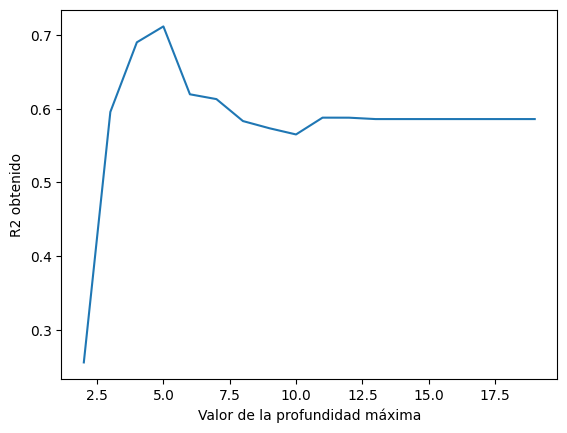

In [27]:
#Representar la validación cruzada
plt.plot(k_range, depth)
plt.xlabel('Valor de la profundidad máxima')
plt.ylabel('R2 obtenido')
plt.show()

In [28]:
print("El valor de K que maximiza el r^2 es", np.argmax(depth) + 2)

El valor de K que maximiza el r^2 es 5


In [30]:
#crear el objeto de clase árbol con profundidad máx de 5
from sklearn.tree import DecisionTreeRegressor

#Crear el objeto de clase árbol num min de muestras 8
tree_clf_d = DecisionTreeRegressor(random_state = 2026, max_depth = 5)
#Ajustar el árbol
tree_clf_d.fit(X_train, y_train)

#from sklearn import tree
#plt.figure(figsize=(14,10))
#tree.plot_tree(tree_clf_d, filled=True)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",2026
,"max_le

In [31]:
#Obtener el mse y el r2
y_pred_d = tree_clf_d.predict(X_test)
r2_d = r2_score(y_test, y_pred_d)
mse_d = mean_squared_error(y_test, y_pred_d)
print("El error cuadratico medio que se tiene es %s" %mse_d)
print("El r2 que se tiene es %s" %r2_d)

El error cuadratico medio que se tiene es 2.2080177277656166
El r2 que se tiene es 0.9804096946178477


In [ ]:
#el mejor modelo es el tree_clf_d

In [32]:
#Obtener la media para la predicción
X_media = np.mean(X_train, axis=0)
#Realizar la predicción
pred_media = tree_clf_d.predict(X_media.values.reshape(1, -1))
print("El precio esperado de la vivienda es %s"%pred_media)

El precio esperado de la vivienda es [22.00352941]


C:\Users\Michelle Jiménez\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
